In [110]:
import numpy as np
import pandas as pd # biblioteka do manipulacji danymi
import os # biblioteka do obsługi systemu operacyjnego - tu do określenia ścieżki folderu roboczego
from tqdm import tqdm # biblioteka implementująca pasek postępu
from ipyfilechooser import FileChooser # biblioteka implementująca widget wyboru folderu lub pliku
import calendar
import matplotlib.pyplot as plt

# def str_to_datetime(date_str):
#     return pd.to_datetime(date_str, format='%Y-%m')

# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

current_dir = os.getcwd()
#data_directory = current_dir + "/unzipped"
#input_file = current_dir + "/" + "merged_file.csv"
dds = current_dir + "/" + "from_python.csv"
# fc = FileChooser(current_dir) 
# fc.show_only_dirs = True 

df = pd.read_csv("merged_file.csv").sort_values(by=['Rok hydrologiczny', 'Wskaźnik półrocza']).drop(['Rodzaj wielkości',"Rok kalendarzowy_od", "Miesiac kalendarzowy_od",'Dzień_od','godzina_od',"Rok kalendarzowy_do", "Miesiac kalendarzowy_do",'Dzień_do','godzina_do'], axis=1).reset_index()
#df = df.groupby(by=["Rok hydrologiczny", 
                   # "Miesiac hydrologiczny",'Miesiac kalendarzowy'
                    #])#.reset_index() #,'Miesiac kalendarzowy'

df = df[df['Wskaźnik ekstremum'] == 3]

# c = df.columns.get_loc('Rok hydrologiczny')
# d = df.columns.get_loc('Mh')

# for i in range(0,len(df)):
#     if df.iloc[i,c] == df.iloc[i+1]

df = df.groupby('Rok hydrologiczny').max().reset_index()
df = df.sort_values('Przepływ [$m^3/s$]', ascending=False).drop(['index', 'Kod stacji', 'Nazwa stacji', 'Nazwa rzeki/jeziora', 'Wskaźnik półrocza', 'Wskaźnik ekstremum'], axis=1).reset_index(drop=True)

df['prawdopodobne emiry [%]'] = (df.index+1) / (len(df) + 1) * 100

# print(len(df))
# print(len(df)+1)

# print(df.index+1)

sto = (100 - df.iloc[len(df)-1,2])
sto1 = (df.iloc[len(df)-1,2] - df.iloc[len(df)-2,2])
sto2 = (df.iloc[len(df)-1,1] - df.iloc[len(df)-2,1])
x = (sto1 * sto2) / sto2

df.head(10)

,Rok hydrologiczny,Przepływ [$m^3/s$],prawdopodobne emiry [%]
0,1952,1450.0,1.388889
1,1980,1410.0,2.777778
2,1974,1210.0,4.166667
3,1964,985.0,5.555556
4,1958,968.0,6.944444
5,1998,962.0,8.333333
6,2004,950.0,9.722222
7,1965,940.0,11.111111
8,1989,935.0,12.500000
9,1955,901.0,13.888889


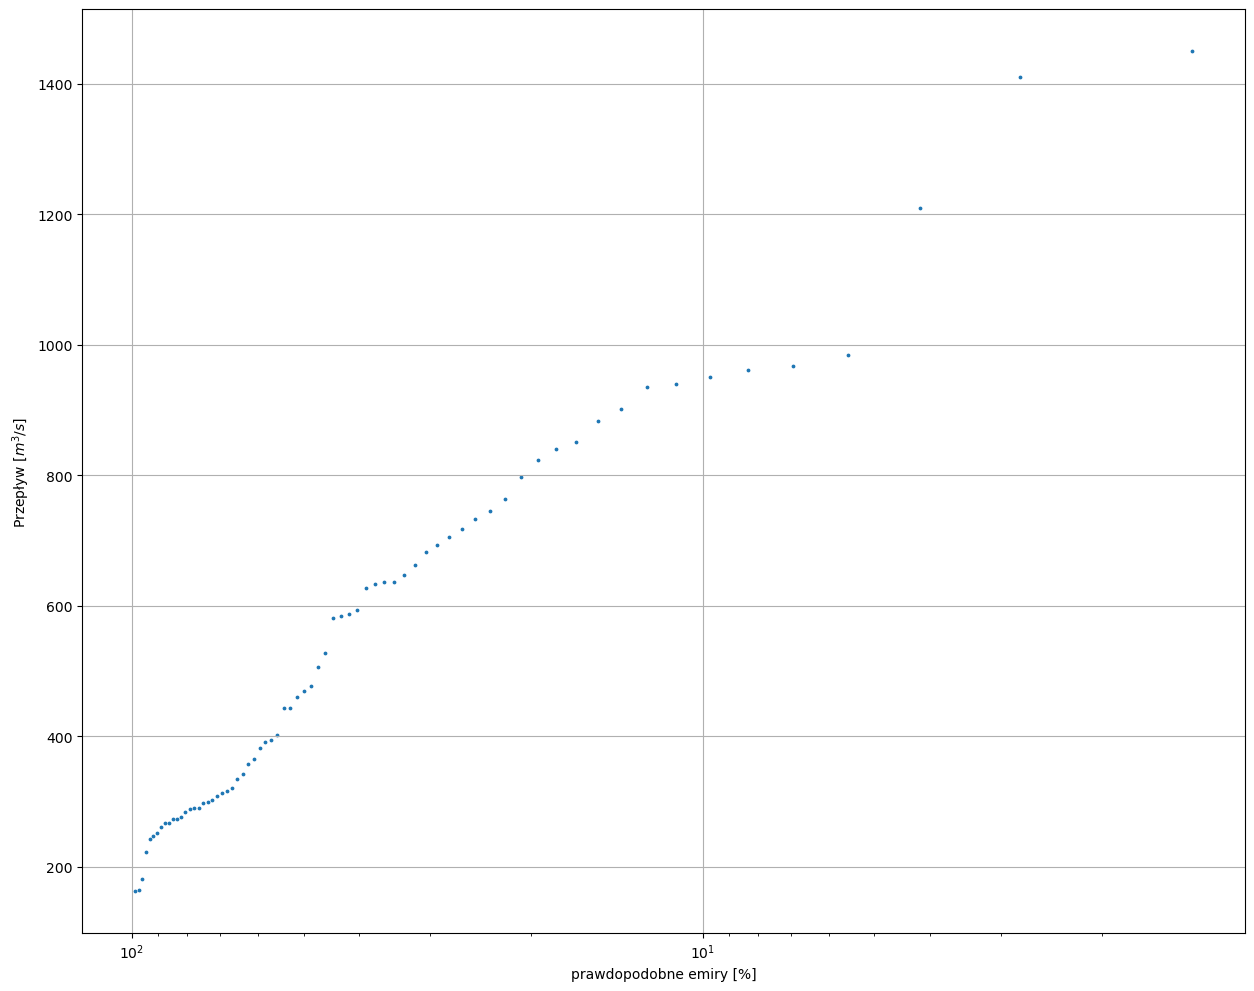

In [111]:
y = df['Przepływ [$m^3/s$]'].to_numpy()
x = df['prawdopodobne emiry [%]'].to_numpy()
plt.figure(figsize=(15,12))
plt.scatter(x,y,s = 3)
plt.gca().invert_xaxis()
plt.gca().set_xscale('log')
plt.xlabel('prawdopodobne emiry [%]')
plt.ylabel('Przepływ [$m^3/s$]')
plt.grid(axis = 'y')
plt.grid(axis = 'x')
plt.show()

# 100% = 159 [$m^3/s$] z interpolacji ocznej:)

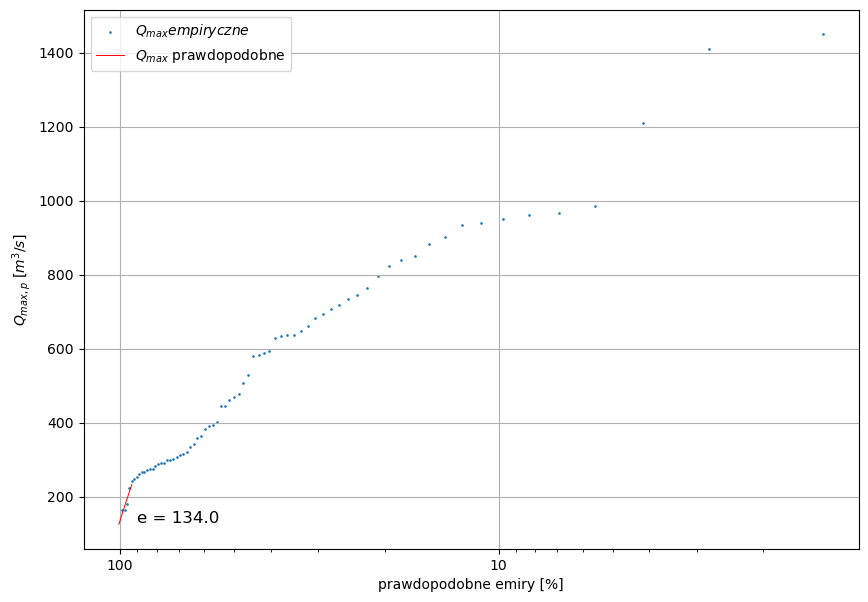

In [118]:
import numpy as np
import matplotlib.pyplot as plt

y = df['Przepływ [$m^3/s$]'].to_numpy()
x = df['prawdopodobne emiry [%]'].to_numpy()

plt.figure(figsize=(10,7))
scatter = plt.scatter(x,y,s = 0.8, label='$Q_{max} empiryczne$')
plt.gca().invert_xaxis()
plt.gca().set_xscale('log')

# Set the tick locations and labels for the x-axis
xtick_locs = [0.1, 1, 10, 100]
xtick_labels = ['0.1', '1', '10', '100']
plt.xticks(xtick_locs, xtick_labels)

X = df['prawdopodobne emiry [%]'][-4:].values.reshape(-1, 1)
y = df['Przepływ [$m^3/s$]'][-4:].values.reshape(-1, 1)
model = LinearRegression()
model.fit(X, y)
# X_plot = np.linspace(93, 100.6).reshape(-1, 1)
y_plot = model.predict(X_plot)

line = plt.plot(X_plot, y_plot, color='red',linewidth=0.7, label='$Q_{max}$ prawdopodobne')

plt.xlabel('prawdopodobne emiry [%]')
plt.ylabel('$Q_{max, p}$ [$m^3/s$]')
plt.grid(axis = 'y')
plt.grid(axis = 'x')
plt.text(90, 130, "e = 134.0", fontsize=12)

legend_handles = [scatter, line]
plt.legend(loc='upper left')

plt.show()

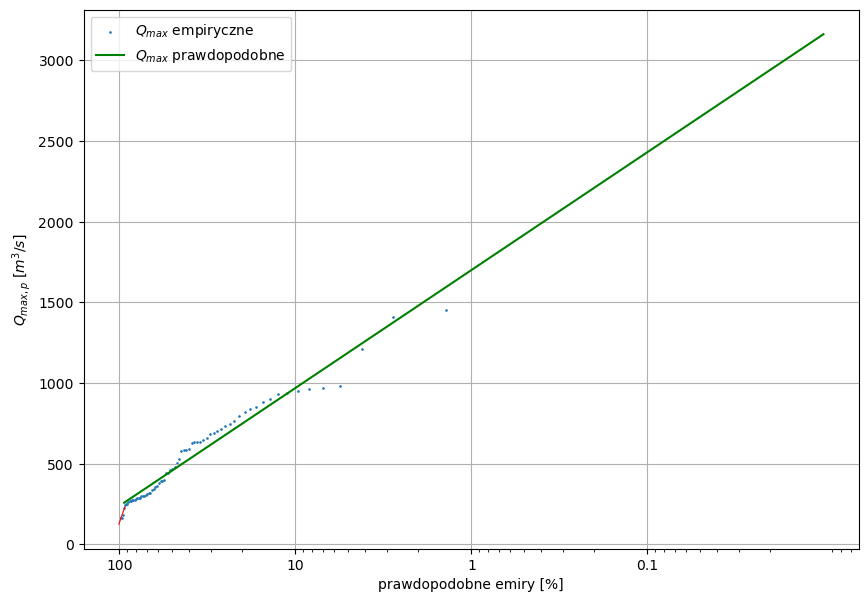

In [119]:
import numpy as np
import matplotlib.pyplot as plt

y = df['Przepływ [$m^3/s$]'].to_numpy()
x = df['prawdopodobne emiry [%]'].to_numpy()

plt.figure(figsize=(10,7))
scatter = plt.scatter(x,y,s = 0.8,  label='$Q_{max}$ empiryczne')
plt.gca().invert_xaxis()
plt.gca().set_xscale('log')

# Set the tick locations and labels for the x-axis
xtick_locs = [0.1, 1, 10, 100]
xtick_labels = ['0.1', '1', '10', '100']
plt.xticks(xtick_locs, xtick_labels)

X = df['prawdopodobne emiry [%]'][-4:].values.reshape(-1, 1)
y = df['Przepływ [$m^3/s$]'][-4:].values.reshape(-1, 1)
model = LinearRegression()
model.fit(X, y)
# X_plot = np.linspace(93, 100.6).reshape(-1, 1)
y_plot = model.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', lw=0.8)

X_1 = df['prawdopodobne emiry [%]']
y_1 = df['Przepływ [$m^3/s$]']
model = LinearRegression()
model.fit(np.log(X_1.values.reshape(-1, 1)), y_1.values.reshape(-1, 1))
X_ext_1 = np.linspace(0.01, 94).reshape(-1, 1)
y_ext_1 = model.predict(np.log(X_ext_1))
line = plt.plot(X_ext_1, y_ext_1,'-', color='green', label='$Q_{max}$ prawdopodobne')

plt.xlabel('prawdopodobne emiry [%]')
plt.ylabel('$Q_{max, p}$ [$m^3/s$]')
plt.grid(axis = 'y')
plt.grid(axis = 'x')

legend_handles = [scatter, line]
plt.legend(loc='upper left')

plt.show()

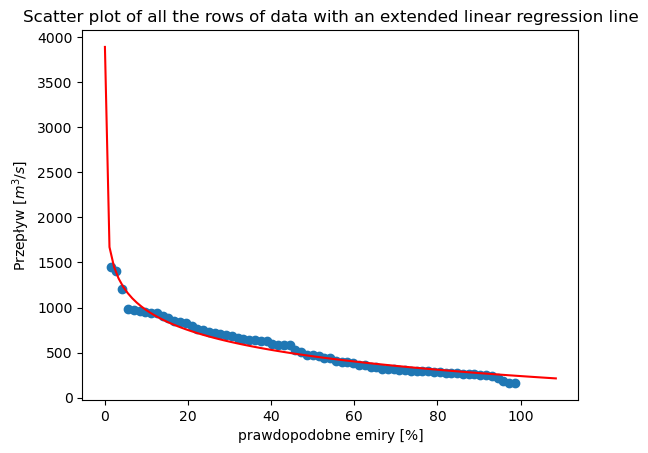

In [33]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Load your dataframe into a pandas dataframe object
# df = pd.read_csv('your_data.csv')

# Use all the rows of data
X = df['prawdopodobne emiry [%]']
y = df['Przepływ [$m^3/s$]']

# Create a linear regression model and fit it to the data
model = LinearRegression()
model.fit(np.log(X.values.reshape(-1, 1)), y.values.reshape(-1, 1))

# Generate a range of values for X to extend the regression line
X_ext = np.linspace(0.001, X.max()*1.1, 100).reshape(-1, 1)

# Use the model to predict the corresponding Y values
y_ext = model.predict(np.log(X_ext))

# Plot the data points and the regression line
plt.scatter(X, y)
plt.plot(X_ext, y_ext, color='red')

# Add axis labels and a title to the plot
plt.xlabel('prawdopodobne emiry [%]')
plt.ylabel('Przepływ [$m^3/s$]')
plt.title('Scatter plot of all the rows of data with an extended linear regression line')

# Show the plot
plt.show()


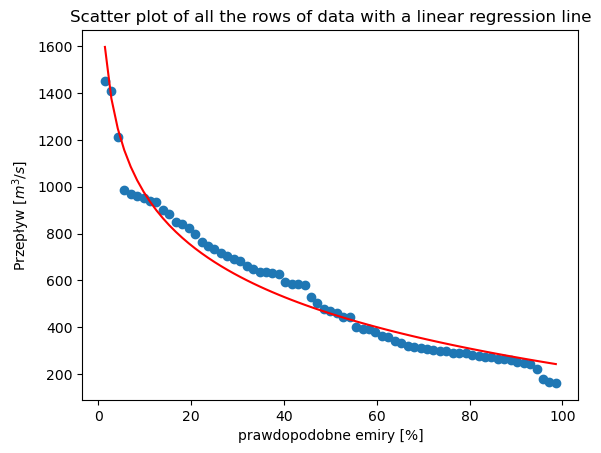

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Load your dataframe into a pandas dataframe object
# df = pd.read_csv('your_data.csv')

# Use all the rows of data
X = df['prawdopodobne emiry [%]']
y = df['Przepływ [$m^3/s$]']

# Create a linear regression model and fit it to the data
model = LinearRegression()
model.fit(np.log(X.values.reshape(-1, 1)), y.values.reshape(-1, 1))

# Use the model to predict the corresponding Y values
y_pred = model.predict(np.log(X.values.reshape(-1, 1)))

# Plot the data points and the regression line
plt.scatter(X, y)
plt.plot(X, y_pred, color='red')

# Add axis labels and a title to the plot
plt.xlabel('prawdopodobne emiry [%]')
plt.ylabel('Przepływ [$m^3/s$]')
plt.title('Scatter plot of all the rows of data with a linear regression line')

# Show the plot
plt.show()


In [5]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load your dataframe into a pandas dataframe object
# df = pd.read_csv('your_data.csv')

# Use only the last 4 rows of data
X = df['prawdopodobne emiry [%]'][-4:].values.reshape(-1, 1)
y = df['Przepływ [$m^3/s$]'][-4:].values.reshape(-1, 1)

# Create a linear regression model and fit it to the data
model = LinearRegression()
model.fit(X, y)

# Use the model to predict the value of 'przepływ' for 'prawdopodobny' = 100
predicted_przeplyw = model.predict([[100]])

# Print the result
print("The predicted value of 'przepływ' for 'prawdopodobny' = 100 based on the last 4 rows of data is approximately:", predicted_przeplyw[0,0])
predicted_przeplyw


The predicted value of 'przepływ' for 'prawdopodobny' = 100 based on the last 4 rows of data is approximately: 134.0


array([[134.]])

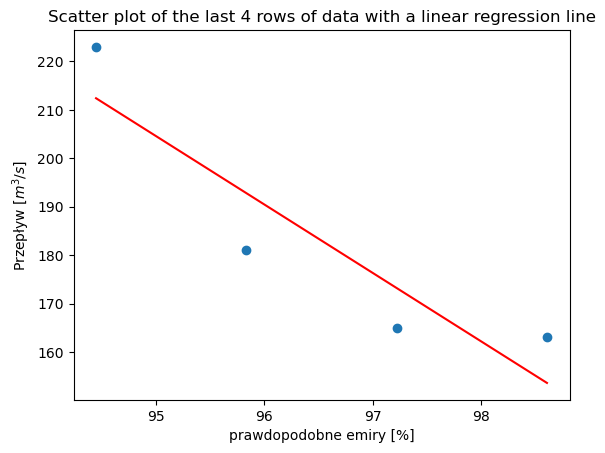

In [6]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load your dataframe into a pandas dataframe object
# df = pd.read_csv('your_data.csv')

# Use only the last 4 rows of data
X = df['prawdopodobne emiry [%]'][-4:].values.reshape(-1, 1)
y = df['Przepływ [$m^3/s$]'][-4:].values.reshape(-1, 1)

# Create a linear regression model and fit it to the data
model = LinearRegression()
model.fit(X, y)

# Use the model to predict the value of 'przepływ' for 'prawdopodobny' = 100
predicted_przeplyw = model.predict([[100]])

# Plot the data points and the regression line
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')

# Add axis labels and a title to the plot
plt.xlabel('prawdopodobne emiry [%]')
plt.ylabel('Przepływ [$m^3/s$]')
plt.title('Scatter plot of the last 4 rows of data with a linear regression line')

# Show the plot
plt.show()


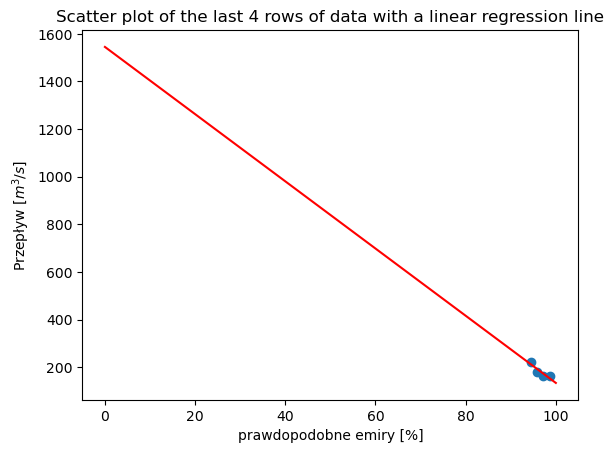

In [10]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Load your dataframe into a pandas dataframe object
# df = pd.read_csv('your_data.csv')

# Use only the last 4 rows of data
X = df['prawdopodobne emiry [%]'][-4:].values.reshape(-1, 1)
y = df['Przepływ [$m^3/s$]'][-4:].values.reshape(-1, 1)

# Create a linear regression model and fit it to the data
model = LinearRegression()
model.fit(X, y)

# Create an array of X values to plot
X_plot = np.linspace(0, 100, 101).reshape(-1, 1)

# Use the model to predict the corresponding Y values
y_plot = model.predict(X_plot)

# Plot the data points and the regression line
plt.scatter(X, y)
plt.plot(X_plot, y_plot, color='red')

# Add axis labels and a title to the plot
plt.xlabel('prawdopodobne emiry [%]')
plt.ylabel('Przepływ [$m^3/s$]')
plt.title('Scatter plot of the last 4 rows of data with a linear regression line')

# Show the plot
plt.show()


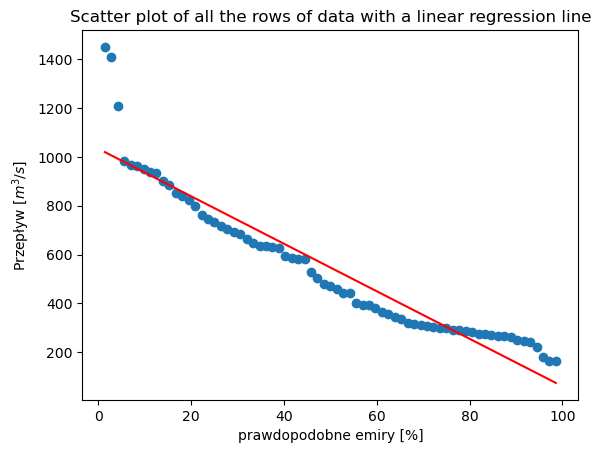

In [23]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load your dataframe into a pandas dataframe object
# df = pd.read_csv('your_data.csv')

# Use all the rows of data
X = df['prawdopodobne emiry [%]'].values.reshape(-1, 1)
y = df['Przepływ [$m^3/s$]'].values.reshape(-1, 1)

# Create a linear regression model and fit it to the data
model = LinearRegression()
model.fit(X, y)

# Use the model to predict the corresponding Y values
y_pred = model.predict(X)

# Plot the data points and the regression line
plt.scatter(X, y)
plt.plot(X, y_pred, color='red')

# Add axis labels and a title to the plot
plt.xlabel('prawdopodobne emiry [%]')
plt.ylabel('Przepływ [$m^3/s$]')
plt.title('Scatter plot of all the rows of data with a linear regression line')

# Show the plot
plt.show()


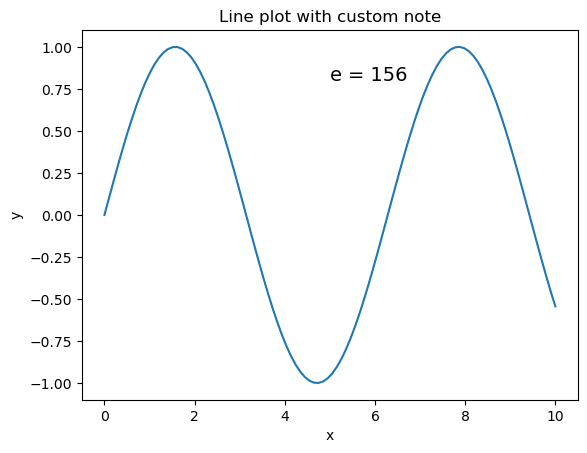

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some data
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Create a line plot
plt.plot(x, y)

# Add a custom note with the symbol "e = 156"
plt.text(5, 0.8, "e = 156", fontsize=14)

# Add axis labels and a title to the plot
plt.xlabel('x')
plt.ylabel('y')
plt.title('Line plot with custom note')

# Show the plot
plt.show()


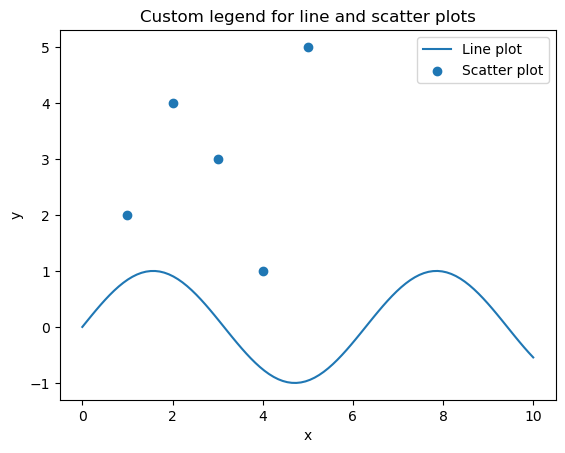

In [112]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
x_scatter = np.array([1, 2, 3, 4, 5])
y_scatter = np.array([2, 4, 3, 1, 5])

# Create a line plot with a label
line, = plt.plot(x, y1, label='Sine wave')

# Create a scatter plot with a label
scatter = plt.scatter(x_scatter, y_scatter, label='Scatter plot')

# Create a custom legend with text labels and symbols
legend_handles = [line, scatter]
legend_labels = ['Line plot', 'Scatter plot']
plt.legend(handles=legend_handles, labels=legend_labels, loc='upper right')

# Add axis labels and a title to the plot
plt.xlabel('x')
plt.ylabel('y')
plt.title('Custom legend for line and scatter plots')

# Show the plot
plt.show()
